# Long-range crash-risk strategies — tick + order book

**Primary deliverable** for multi-day marked-maker equity under crash risk overlays.

| | |
|--|--|
| Date span | **2026-08-28 → 2026-09-30** |
| Days in | **27** (ETH) · probed 34 |
| Venue focus | Hyperliquid (Deribit TOB when joined for book honesty) |
| Friction | **2.0 bps** one-way |
| Best overlay (risk) | **`kill_ladder_maker`** |

Sibling: [`../expanded_lab/`](../expanded_lab/) = event-study risk scoreboard + shared quote stubs.  
This lab = **tick/OB equity paths** over the PIN-usable long panel; reuses expanded panel events when present.

## Strategies

| Stub | Role |
|------|------|
| `baseline_maker` | Always-on small touch maker |
| `kill_ladder_maker` | Ladder size / halt pull |
| `nanex_temp_pull` | Nanex∩SSM temporary escalate/pull |
| `ladder_plus_v_restore` | Ladder × V-confirm restore (expanded_lab stub) |
| `confirm_before_restore` | Dual-horizon V confirm (expanded_lab stub) |
| `ladder_plus_confirm_before_restore` | Ladder × dual-horizon confirm (combined best) |

**Class (this section):** risk-policy / MM playbook — **not** naked tradable alpha.

**Also in this lab:** non-MM minutes–hours edges (`run_long_edges.py` → `out/long_edges/`) — crash/SSM/V-class holds distinct from edge_lab mo@5s V-fade. See section **Non-MM long-hold edges** below.

## Cadence honesty

Trade tape is ms-level. Book sources this run: {'warehouse:l2_rebuild': 10, 'warehouse:l2_snapshot_level': 1, 'tape_proxy': 4, 'collector': 1}. Median book Δt ≈ 5.39s. Collector TOB preferred when present; else HL `l2_snapshot_level` / warehouse BBO (~seconds–minutes median) or Deribit TOB — **not** sub-second L2. Equity = synthetic touch-maker marks with friction; fills at trade print + fill_i.

Fills book at **trade print** + `fill_i` (never stale asof bid/ask as fill px).


In [3]:

import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

OUT = Path('out')
s = json.loads((OUT / 'summary.json').read_text())
cov = pd.DataFrame(json.loads((OUT / 'coverage.json').read_text()))
if 'included' not in cov.columns and 'in' in cov.columns:
    cov = cov.rename(columns={'in': 'included'})
cov['included'] = cov['included'].astype(bool)

print('span', s['date_span'], 'n_days_in', s['n_days_in'], 'n_cells_ok', s['n_cells_ok'])
print('winner', s['winner'])
print('fire_scoreboard', s['fire_scoreboard'])
print()
for name, block in s['strategies'].items():
    d = block['delta_vs_baseline']
    print(f"{name:36s} eq_mean={block['pool']['final_equity_bps']['mean']:+9.2f}  "
          f"dd_mean={block['pool']['max_dd_bps']['mean']:+9.2f}  "
          f"Δeq={d['delta_mean']:+8.2f} CI=[{d.get('lo', float('nan')):+.1f},{d.get('hi', float('nan')):+.1f}]")


span {'first': '2026-08-28', 'last': '2026-09-30'} n_days_in 27 n_cells_ok 27
winner {'ranked': ['kill_ladder_maker', 'ladder_plus_v_restore', 'ladder_plus_confirm_before_restore', 'nanex_temp_pull', 'confirm_before_restore'], 'best': 'kill_ladder_maker', 'note': 'Ranked by mean ΔmaxDD vs baseline (less severe first), then Δequity'}
fire_scoreboard {'n_fire': 199, 'n_control': 43, 'fp_v_recovery_rate': 0.7537688442211056, 'n_v_among_fire': 150, 'adverse_mo5_fire_mean': 21.442732867885795, 'adverse_mo5_control_mean': 11.815102327358103, 'delta_adverse_mo5': 9.627630540527692}

baseline_maker                       eq_mean= -2464.41  dd_mean= -3480.74  Δeq=   +0.00 CI=[+0.0,+0.0]
kill_ladder_maker                    eq_mean= -2450.63  dd_mean= -3466.27  Δeq=  +13.79 CI=[-14.9,+50.1]
nanex_temp_pull                      eq_mean= -2453.69  dd_mean= -3470.80  Δeq=  +10.73 CI=[-13.1,+45.8]
ladder_plus_v_restore                eq_mean= -2449.71  dd_mean= -3466.55  Δeq=  +14.70 CI=[-14.8,+52.8]

## Date coverage (in / out)

,day,included,reason,n_trades,coverage,pin_usable,panel_core,thin_public_md
0,2026-08-28,True,ok,207371,0.950238,True,False,False
1,2026-08-29,True,ok,288897,0.994577,True,False,False
2,2026-08-30,True,ok,268282,0.984537,True,False,False
3,2026-08-31,True,ok,3368,0.460627,True,False,False
4,2026-09-01,True,ok,51254,0.404114,True,False,False
5,2026-09-02,True,ok,45688,0.796979,True,False,False
6,2026-09-03,True,ok,122101,0.998892,True,False,False
7,2026-09-04,True,ok,113682,0.999342,True,True,False
8,2026-09-05,True,ok,103356,0.990116,True,True,False
9,2026-09-06,True,ok,130518,0.990635,True,True,False


IN days: ['2026-08-28', '2026-08-29', '2026-08-30', '2026-08-31', '2026-09-01', '2026-09-02', '2026-09-03', '2026-09-04', '2026-09-05', '2026-09-06', '2026-09-07', '2026-09-08', '2026-09-09', '2026-09-10', '2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-20', '2026-09-21', '2026-09-22', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-30']
OUT days: ['2026-09-11', '2026-09-12', '2026-09-13', '2026-09-23', '2026-09-24', '2026-09-28', '2026-09-29']


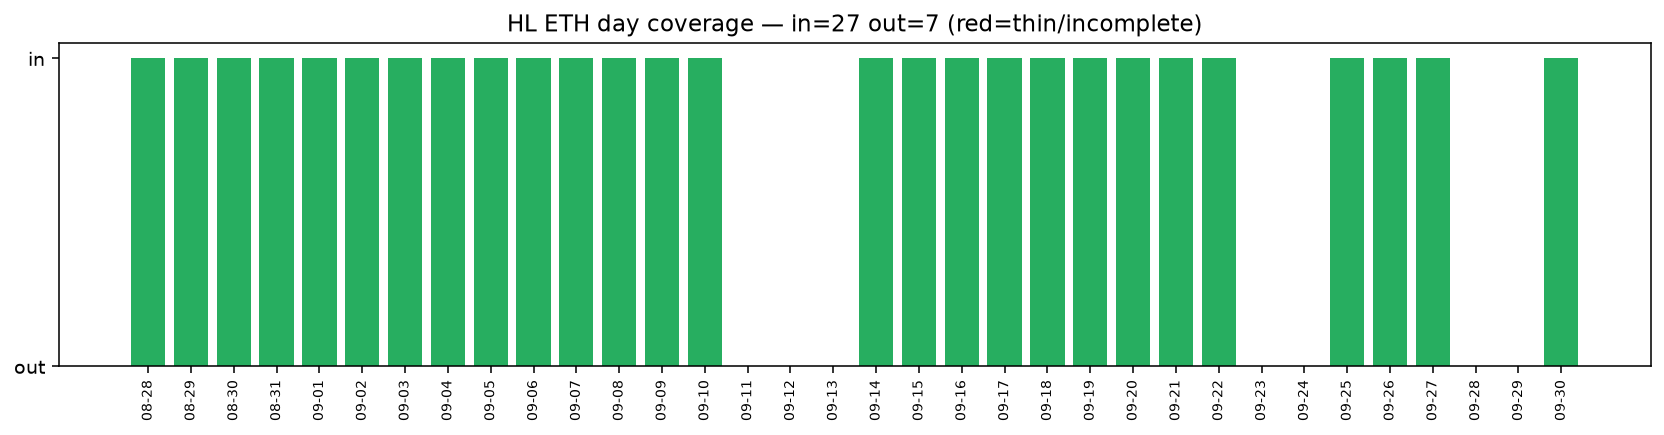

In [4]:

eth = cov[cov.symbol == 'ETH'].sort_values('day')
display(eth[['day', 'included', 'reason', 'n_trades', 'coverage', 'pin_usable', 'panel_core', 'thin_public_md']])
print('IN days:', eth.loc[eth['included'], 'day'].tolist())
print('OUT days:', eth.loc[~eth['included'], 'day'].tolist())
if (OUT / 'figs' / 'coverage_days.png').exists():
    display(Image(filename=str(OUT / 'figs' / 'coverage_days.png')))


## Aggregate equity / inventory / drawdown

PNGs under `out/figs/`.

### `equity_cumulative.png`

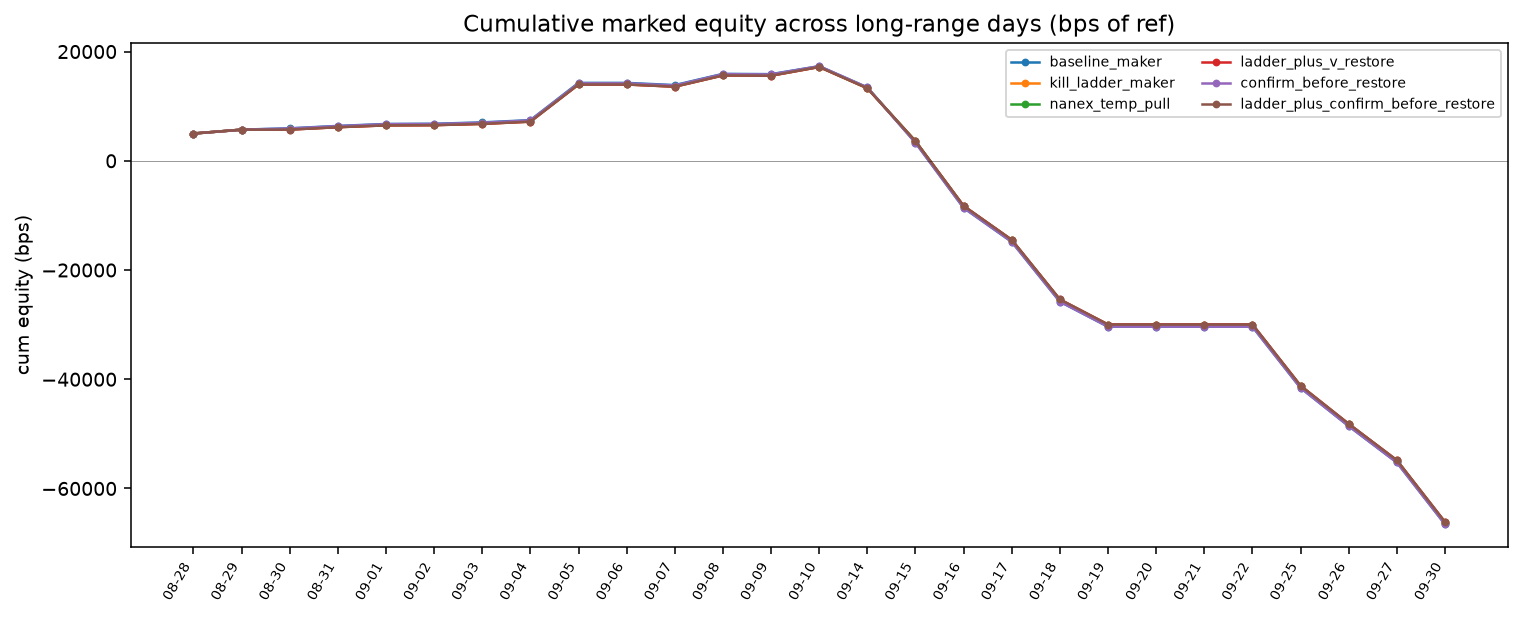

### `drawdown_scoreboard.png`

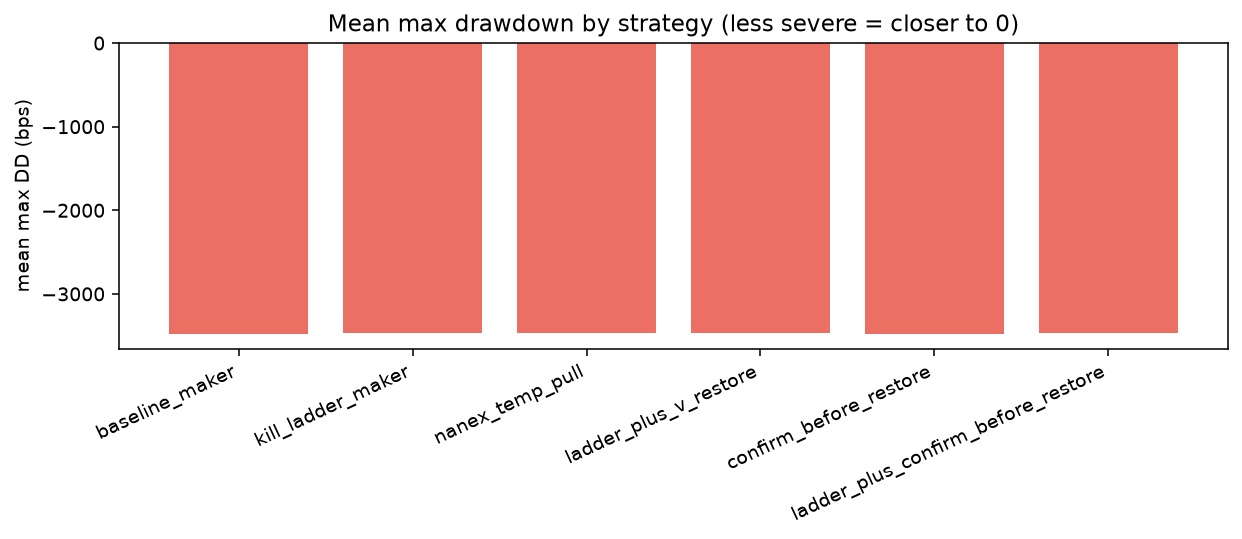

### `delta_vs_baseline.png`

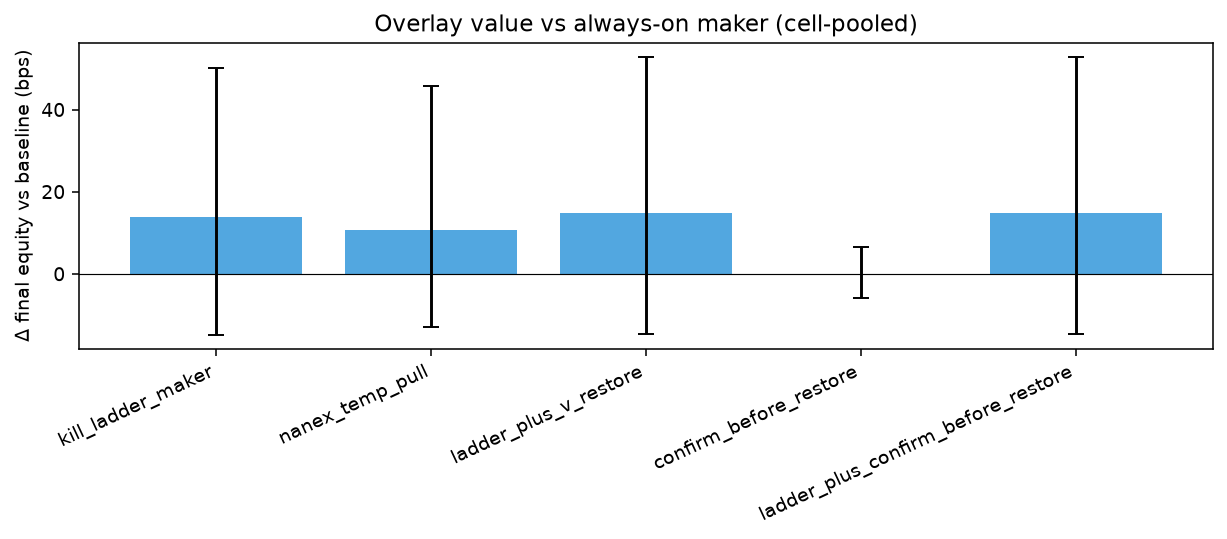

### `example_day_inventory.png`

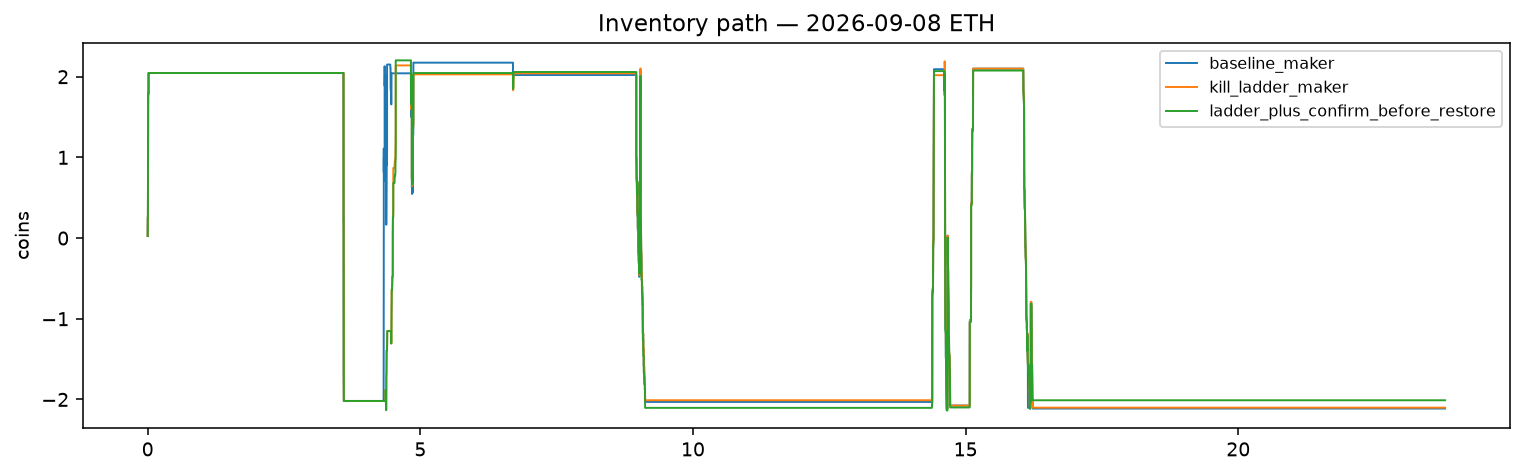

In [5]:

from IPython.display import Image, display, Markdown
for name in [
    'equity_cumulative.png',
    'drawdown_scoreboard.png',
    'delta_vs_baseline.png',
    'example_day_inventory.png',
]:
    p = OUT / 'figs' / name
    if p.exists():
        display(Markdown(f'### `{name}`'))
        display(Image(filename=str(p)))


## Risk scoreboard

Adverse |mo5| after fires · FP V-recovery rate · fire counts.

- **n_fire**=199 · **n_control**=43
- **FP V-recovery rate**=0.754 (fires labeled `v_recovery`)
- **adverse |mo5| fire**=21.44 · control=11.82
- **Δ adverse**=9.63 (fire − control; higher = fires are worse tails — ladder targets these)


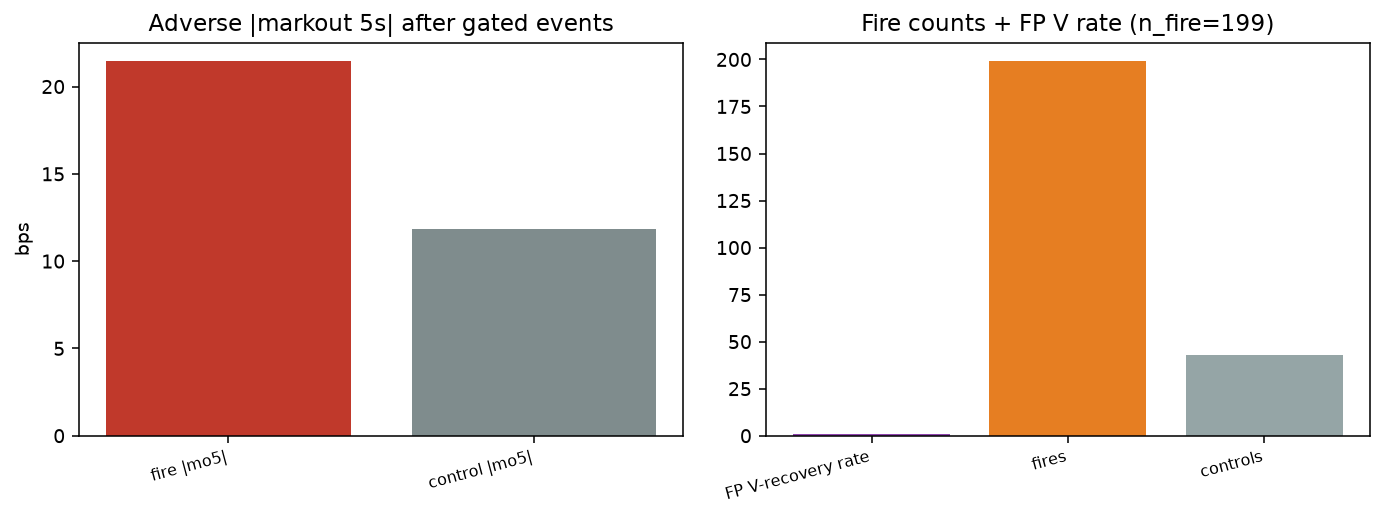

In [6]:

fs = s['fire_scoreboard']
display(Markdown(
    f"""- **n_fire**={fs['n_fire']} · **n_control**={fs['n_control']}
- **FP V-recovery rate**={fs['fp_v_recovery_rate']:.3f} (fires labeled `v_recovery`)
- **adverse |mo5| fire**={fs['adverse_mo5_fire_mean']:.2f} · control={fs['adverse_mo5_control_mean']:.2f}
- **Δ adverse**={fs['delta_adverse_mo5']:.2f} (fire − control; higher = fires are worse tails — ladder targets these)
"""
))
display(Image(filename=str(OUT / 'figs' / 'risk_scoreboard.png')))


## Example day zoom — price + fills + ladder shades

Focus cell: `{'day': '2026-09-08', 'symbol': 'ETH', 'venue': 'hyperliquid', 'n_events': 82, 'book': {'available': 1, 'source': 'warehouse:l2_snapshot_level:iid=3045026857', 'table': 'l2_snapshot_level', 'n': 252, 'median_dt_s': 349.196, 'has_l2_depth': 0, 'cadence_note': 'HL l2_snapshot_level rebuild (~minutes median on flat-era); not ms L2'}}`

### `example_day_equity.png`

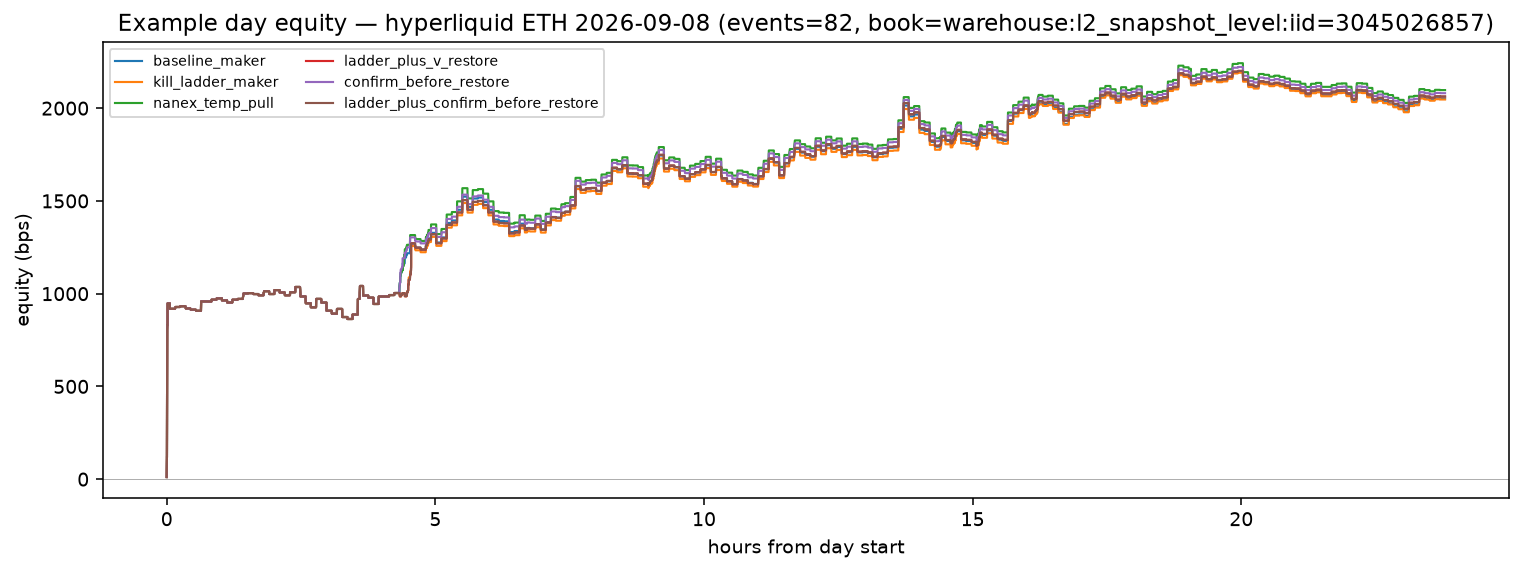

### `example_day_price_fills.png`

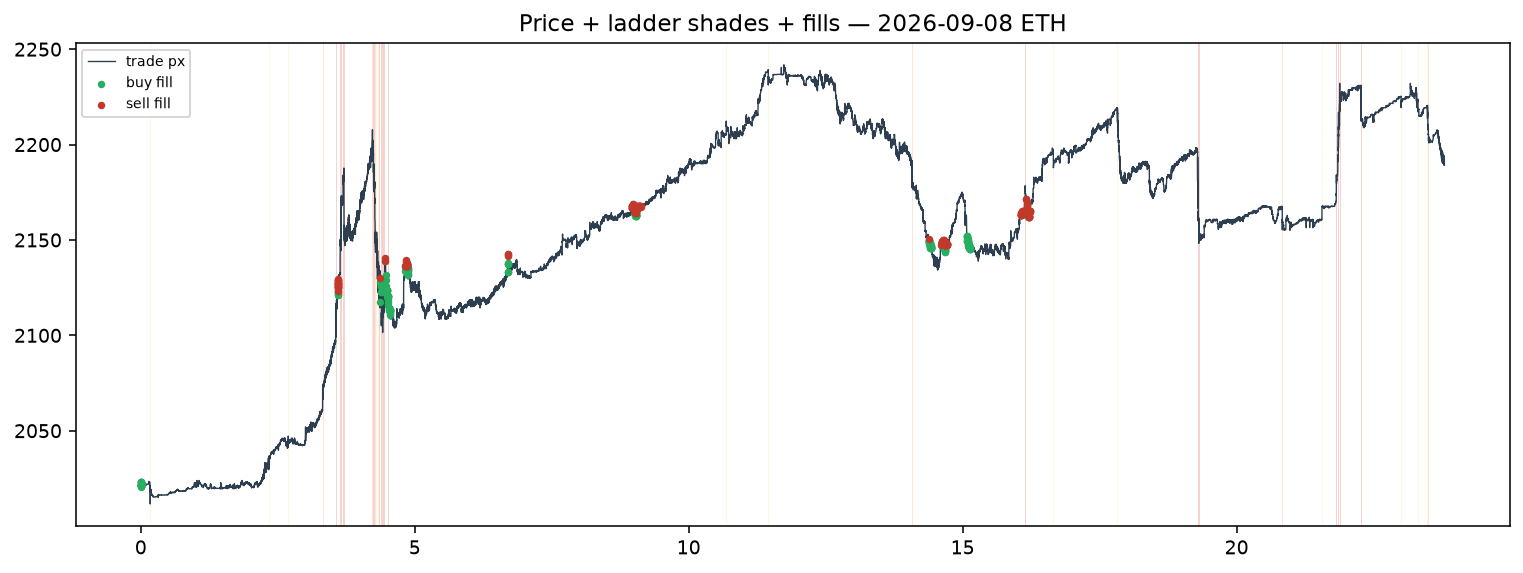

In [7]:

display(Markdown(f"Focus cell: `{s.get('focus_cell')}`"))
for name in ['example_day_equity.png', 'example_day_price_fills.png']:
    p = OUT / 'figs' / name
    if p.exists():
        display(Markdown(f'### `{name}`'))
        display(Image(filename=str(p)))


## Early vs late half stability

kill_ladder_maker                    early=+1199.01 (n=13)  late=-5839.58 (n=14)  sign_stable=0
nanex_temp_pull                      early=+1209.67 (n=13)  late=-5855.37 (n=14)  sign_stable=0
ladder_plus_v_restore                early=+1198.95 (n=13)  late=-5837.75 (n=14)  sign_stable=0
confirm_before_restore               early=+1216.55 (n=13)  late=-5882.35 (n=14)  sign_stable=0
ladder_plus_confirm_before_restore   early=+1198.95 (n=13)  late=-5837.75 (n=14)  sign_stable=0


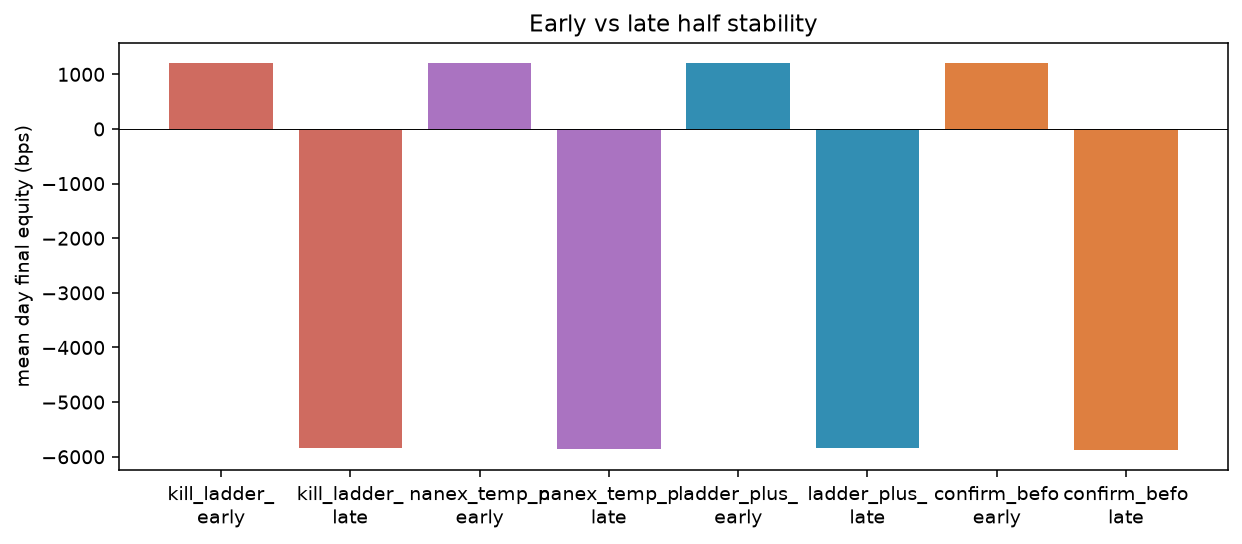

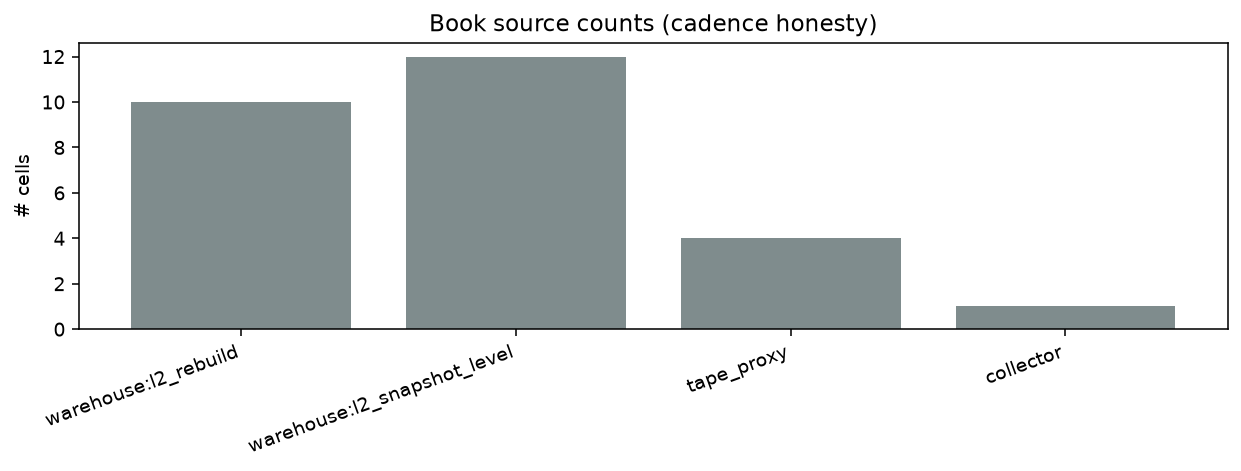

In [8]:

for name, block in s['strategies'].items():
    if name == 'baseline_maker':
        continue
    el = block['early_late']
    print(f"{name:36s} early={el['early_mean_final_bps']:+.2f} (n={el['early_n_days']})  "
          f"late={el['late_mean_final_bps']:+.2f} (n={el['late_n_days']})  "
          f"sign_stable={el['sign_stable']}")
display(Image(filename=str(OUT / 'figs' / 'early_late_split.png')))
display(Image(filename=str(OUT / 'figs' / 'book_source_counts.png')))


## Headline

**Best risk overlay on this long panel:** `kill_ladder_maker`

Ranked: `['kill_ladder_maker', 'ladder_plus_v_restore', 'ladder_plus_confirm_before_restore', 'nanex_temp_pull', 'confirm_before_restore']`

Re-run: `python3 run_long_range.py --workers 8` · see [`README.md`](README.md).
Wire: `expanded_lab` panel + quote stubs · `paper_harness.detect_day` (off-panel days) · `strategy_lab.run_tick_sim` (fills at trade print).


## Non-MM long-hold edges (minutes–hours)

Separate from MM overlays and from [`../edge_lab/`](../edge_lab/) **mo@5s** V-fade.
Uses gated SSM + causal V/cont@2s + multi-event clusters; holds **1m–60m**.

| Artifact | Path |
|----------|------|
| Report | [`out/long_edges/EXP_REPORT.md`](out/long_edges/EXP_REPORT.md) |
| Summary | [`out/long_edges/summary.json`](out/long_edges/summary.json) |
| Figs | [`out/long_edges/figs/`](out/long_edges/figs/) |

```bash
python3 run_long_edges.py --workers 8
python3 run_long_edges.py --rescore
```


In [ ]:
from pathlib import Path
import json
from IPython.display import Image, display, Markdown

LE = Path('out/long_edges')
le = json.loads((LE / 'summary.json').read_text())
print('generated', le['generated_at'])
print('n_events', le['meta']['n_events'], 'days_with_events', le['meta']['n_days_ok'])
print()
for name, block in le['lenses'].items():
    p = block['primary']
    v = block['primary_verdict']
    ci = p['pnl_net_bps']
    hold = str(p.get('hold', '')).replace('mo_', '')
    print(
        f"{name:22s} @{hold:4s} → {v['decision']:7s}  "
        f"mean={ci['mean']:+8.2f} CI=[{ci['lo']:+.1f},{ci['hi']:+.1f}] n={p['n_traded']}  | {v['why'][:70]}"
    )

v = le['lenses']['LR-v-slow-fade']
cm = v['class_mo_15m_causal']
display(Markdown(
    f"**Causal class mo@15m:** V={cm['v_recovery']['mean']:.1f} · "
    f"cont={cm['continuation']['mean']:.1f} · partial={cm['partial']['mean']:.1f} bps "
    f"(crash-signed — positive ⇒ continuation in crash direction)"
))


### Long-edge figures

Green = Promote · amber = Hold · red = Kill. Cluster ride is the anti-fade after cascade; fire-pause is a risk gate (Δ|mo|), not naked taker PnL.


In [ ]:
fig_dir = LE / 'figs'
for name in [
    'fig_scoreboard_long_edges.png',
    'fig_class_mo_15m.png',
    'fig_v_slow_fade_by_hold.png',
    'fig_cont_long_ride_by_hold.png',
    'fig_cluster_fade_vs_ride.png',
    'fig_fire_pause_delta_mo.png',
    'fig_ssm_drift_ride.png',
    'fig_cum_equity_primary.png',
    'fig_drift_early_late.png',
]:
    p = fig_dir / name
    if p.exists():
        display(Markdown(f'**{name}**'))
        display(Image(filename=str(p)))
    else:
        print('missing', p)


### Non-MM headline

- **LR-fire-pause @5m → Promote** — fire-tier |mo| ≫ observe (Δ≈+19.8bps CI[5.6,32.2], n_fire=194); long-horizon intensity pause (edge_lab TI-int-halt analogue beyond 5s).
- **LR-cluster-ride @60m → Hold** — cascade anti-fade mean +46bps but **n=12 underpowered**; fade@15m/60m is a significant **anti-edge** (Kill).
- **LR-v-slow-fade → Kill** — edge_lab short V-fade does **not** extend to minutes–hours (causal class mo@15m: V≈+6 / cont≈+21 crash-signed).
- **LR-cont-long-ride / LR-ssm-drift-ride → Hold** — positive means at 15–30m, CI includes 0.

Honesty: research_sim · 4bps RT · not live alpha · no MM deepen · no ClickHouse MCP.
